# Práctica 2: Clustering de semillas

## Paso 1: Comparación visual de escaladores con PCA

En este bloque se aplica Principal Component Analysis (PCA) a los datos de semillas usando tres escaladores distintos: `StandardScaler`, `MinMaxScaler` y `RobustScaler`. 

Se visualiza para cada escalador:
1. La varianza explicada por cada componente principal.
2. La representación de los datos en 2D según las dos primeras componentes.

Esto permitirá elegir el escalador más adecuado antes de aplicar técnicas de clustering.

In [6]:
# 📌 Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Configuración
seed = 313697  # NIA del estudiante
plt.style.use('ggplot')

In [7]:
# 📌 Cargar y preparar los datos
df = pd.read_csv('../data/semillas.csv')
print(df.columns)
X = df.drop(columns=['clase'])  # Cambia si el nombre es diferente

Index(['area', 'perimetro', 'compacidad', 'longitud', 'anchura', 'asimetria',
       'surco', 'clase'],
      dtype='object')


In [8]:
# 📌 Función para visualizar varianza explicada por PCA
def mostrar_varianza(X, scaler, nombre_scaler):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA())
    ])
    X_pca = pipe.fit_transform(X)
    pca = pipe.named_steps['pca']
    varianza_explicada = pca.explained_variance_ratio_
    varianza_acumulada = np.cumsum(varianza_explicada)

    # Gráfico de varianza
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual', color='blue')
    plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

    for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
        plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
        plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

    plt.xlabel('Componentes Principales')
    plt.ylabel('Varianza Explicada')
    plt.title(f'Varianza explicada por PCA - {nombre_scaler}')
    plt.legend(loc='best')
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()



In [9]:
# 📌 Función para visualizar proyección 2D de PCA
def mostrar_pca_2d(X, scaler, nombre_scaler, seed):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=2, random_state=seed))
    ])
    X_2d = pipe.fit_transform(X)
    pca_2d = pipe.named_steps['pca']

    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=40, alpha=0.7, color='blue')
    plt.title(f'PCA 2D - {nombre_scaler}\n(Varianza: {pca_2d.explained_variance_ratio_[0]:.2%} + {pca_2d.explained_variance_ratio_[1]:.2%})')
    plt.xlabel(f'Componente 1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'Componente 2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
    plt.grid(True)
    plt.show()

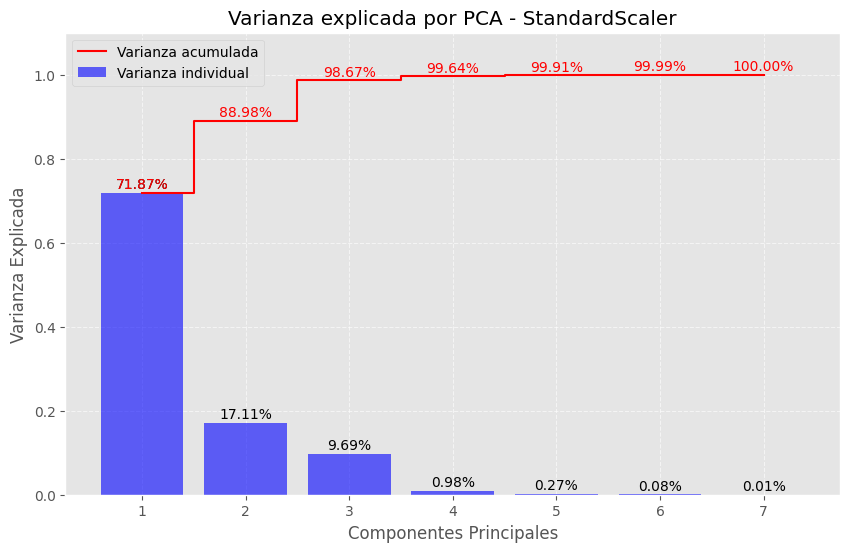

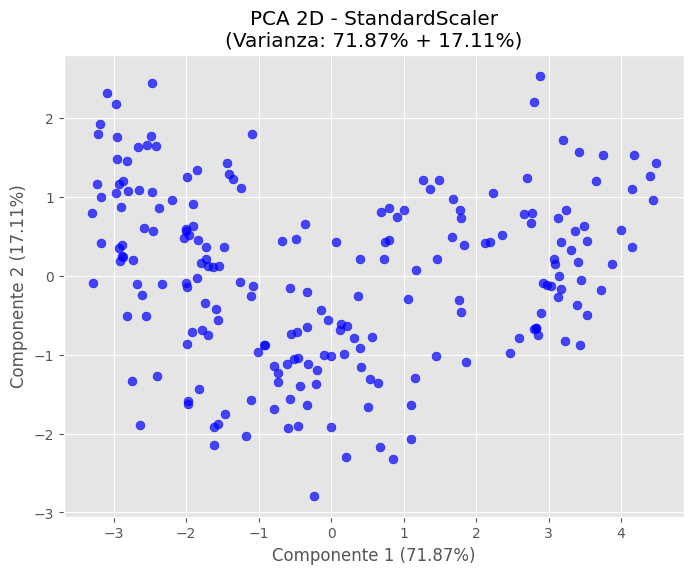

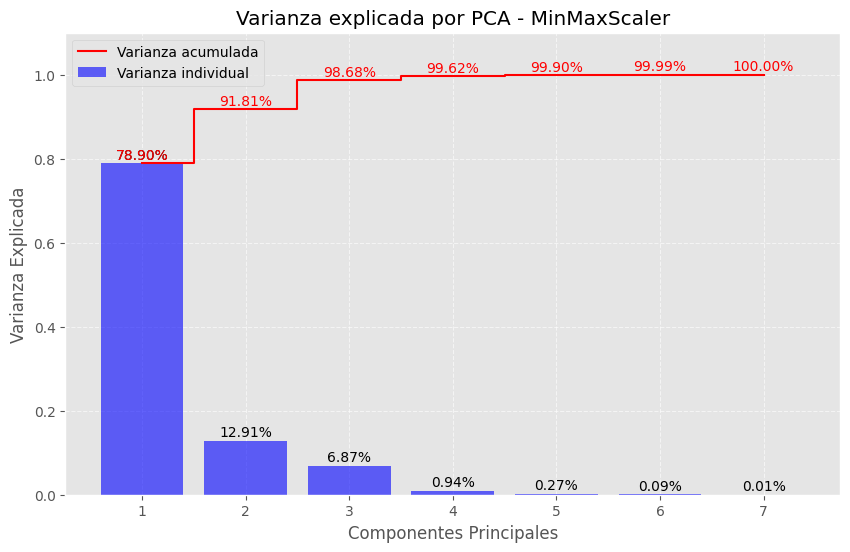

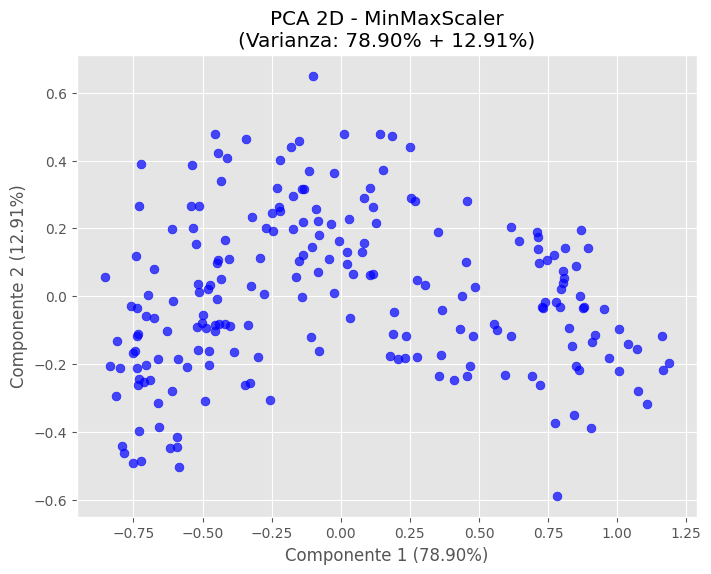

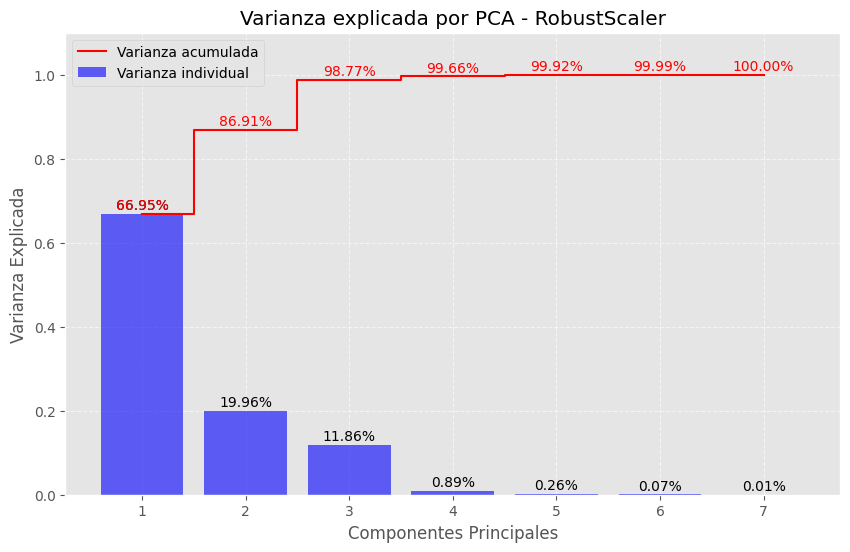

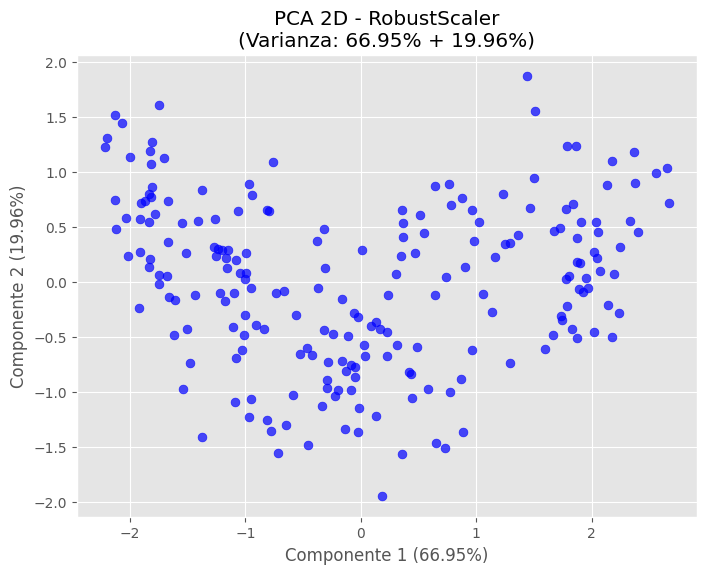

In [10]:
# 📌 Ejecutar para cada escalador

# StandardScaler
mostrar_varianza(X, StandardScaler(), 'StandardScaler')
mostrar_pca_2d(X, StandardScaler(), 'StandardScaler', seed)

# MinMaxScaler
mostrar_varianza(X, MinMaxScaler(), 'MinMaxScaler')
mostrar_pca_2d(X, MinMaxScaler(), 'MinMaxScaler', seed + 1)

# RobustScaler
mostrar_varianza(X, RobustScaler(), 'RobustScaler')
mostrar_pca_2d(X, RobustScaler(), 'RobustScaler', seed + 2)